# Data Preprocessing for HR Retention

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df = pd.read_csv("/content/HumanResources-Dataset.csv")
df.info(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   employee_id         8950 non-null   object
 1   first_name          8950 non-null   object
 2   last_name           8950 non-null   object
 3   gender              8950 non-null   object
 4   state               8950 non-null   object
 5   city                8950 non-null   object
 6   hiredate            8950 non-null   object
 7   department          8950 non-null   object
 8   job_title           8950 non-null   object
 9   education_level     8950 non-null   object
 10  salary              8950 non-null   int64 
 11  performance_rating  8950 non-null   object
 12  overtime            8950 non-null   object
 13  birthdate           8950 non-null   object
 14  termdate            3128 non-null   object
dtypes: int64(1), object(14)
memory usage: 1.0+ MB


In [74]:
df.head(10)

,employee_id,first_name,last_name,gender,state,city,hiredate,department,job_title,education_level,salary,performance_rating,overtime,birthdate,termdate
0,00-95822412,Danielle,Johnson,Female,New York,Buffalo,2016-04-10,Customer Service,Help Desk Technician,High School,81552,Good,No,1981-05-13,2017-08-09
1,00-42868828,Jeffrey,Doyle,Male,North Carolina,Charlotte,2017-09-04,IT,System Administrator,Bachelor,107520,Good,No,1988-12-21,2021-01-15
2,00-83197857,Patricia,Miller,Male,New York,New York City,2016-06-03,Operations,Logistics Coordinator,Bachelor,61104,Good,Yes,1995-04-19,2016-11-30
3,00-13999315,Anthony,Robinson,Male,New York,Rochester,2016-07-03,Operations,Inventory Specialist,Bachelor,73770,Good,No,1981-03-24,2020-02-09
4,00-90801586,Anthony,Gonzalez,Female,New York,Rochester,2015-08-25,Operations,Operations Analyst,Bachelor,55581,Satisfactory,No,1985-12-01,2021-05-12
5,00-97226012,Amy,Robinson,Female,New York,New York City,2022-08-03,Operations,Operations Analyst,Bachelor,73800,Good,Yes,1990-07-17,2023-09-23
6,00-70291817,Lisa,Smith,Male,New York,Buffalo,2020-10-21,Finance,Accountant,Bachelor,68181,Good,No,1993-09-01,2021-04-19
7,00-31429110,Helen,Peterson,Female,New York,Buffalo,2022-02-26,Finance,Accounts Payable Specialist,Bachelor,54499,Good,Yes,1997-09-10,2022-08-25
8,00-30868105,Susan,Rogers,Male,New York,Buffalo,2017-02-03,Operations,Inventory Specialist,High School,57340,Good,No,2003-01-29,2021-06-26
9,00-22448136,Colin,Abbott,Female,New York,Rochester,2018-08-08,Operations,Logistics Coordinator,Bachelor,54065,Good,Yes,1982-03-05,2023-01-30


In [75]:
df.shape

(8950, 15)

In [76]:
df.dtypes

,0
employee_id,object
first_name,object
last_name,object
gender,object
state,object
city,object
hiredate,object
department,object
job_title,object
education_level,object


In [77]:
df.describe(include=['object','category'])

,employee_id,first_name,last_name,gender,state,city,hiredate,department,job_title,education_level,performance_rating,overtime,birthdate,termdate
count,8950,8950,8950,8950,8950,8950,8950,8950,8950,8950,8950,8950,8950,3128
unique,8950,644,978,2,8,24,3230,7,28,4,4,2,6731,1857
top,00-50413766,Michael,Smith,Male,New York,Rochester,2022-04-29,Operations,Logistics Coordinator,Bachelor,Good,No,1988-01-27,2023-10-18
freq,1,184,193,4801,6270,2100,11,2718,1061,5418,4449,6240,5,7


In [78]:
# check and remove duplicates
dup_count = df.duplicated().sum()
print(f"Number of duplicate rows: {dup_count}")

if dup_count > 0:
    df = df.drop_duplicates()
    print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


In [79]:
#Find the missing values
df.isna().sum()




,0
employee_id,0
first_name,0
last_name,0
gender,0
state,0
city,0
hiredate,0
department,0
job_title,0
education_level,0


## Create imputation to check if this can be applied to HR dataset to find HR retention

In [80]:
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include="object").columns

# Numeric Imputation: median
for col in num_cols:
    if df[col].isna().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Imputed numeric column '{col}' with median {median_val}")

# Categorical Imputation: mode
for col in cat_cols:
    if df[col].isna().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"Imputed categorical column '{col}' with mode '{mode_val}'")

print("\nMissing values after imputation (excluding termdate):")
print(df.drop(columns=["termdate"]).isna().sum())#

Imputed categorical column 'termdate' with mode '2023-10-18'

Missing values after imputation (excluding termdate):
employee_id           0
first_name            0
last_name             0
gender                0
state                 0
city                  0
hiredate              0
department            0
job_title             0
education_level       0
salary                0
performance_rating    0
overtime              0
birthdate             0
dtype: int64


/tmp/ipython-input-3281359574.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


## Bring back the original dataset since imputation is not working in our dataset

In [81]:
df = pd.read_csv("/content/HumanResources-Dataset.csv")
df.describe(include=['object','category'])

,employee_id,first_name,last_name,gender,state,city,hiredate,department,job_title,education_level,performance_rating,overtime,birthdate,termdate
count,8950,8950,8950,8950,8950,8950,8950,8950,8950,8950,8950,8950,8950,3128
unique,8950,644,978,2,8,24,3230,7,28,4,4,2,6731,1857
top,00-50413766,Michael,Smith,Male,New York,Rochester,2022-04-29,Operations,Logistics Coordinator,Bachelor,Good,No,1988-01-27,2023-10-18
freq,1,184,193,4801,6270,2100,11,2718,1061,5418,4449,6240,5,7


In [82]:
# Create terminated column (1 = terminated, 0 = not terminated)
if "termdate" in df.columns:
    df["terminated"] = df["termdate"].notna().astype(int)
    print("\nTerminated value counts:")
    print(df["terminated"].value_counts())
else:
    raise ValueError("termdate column not found; cannot create 'terminated' label.")


Terminated value counts:
terminated
0    5822
1    3128
Name: count, dtype: int64


In [83]:
# Rechecking missing values after creating terminated column
print("\nMissing values after type conversion:")
print(df.isna().sum())


Missing values after type conversion:
employee_id              0
first_name               0
last_name                0
gender                   0
state                    0
city                     0
hiredate                 0
department               0
job_title                0
education_level          0
salary                   0
performance_rating       0
overtime                 0
birthdate                0
termdate              5822
terminated               0
dtype: int64


In [84]:
# Rechecking missing column after creating terminated column
def percent_missing_by_col(df: pd.DataFrame) -> pd.Series:
    return df.isna().mean().sort_values(ascending=False) * 100.0
miss_by_col = percent_missing_by_col(df)
print("\n% missing per column (descending):\n", miss_by_col)


% missing per column (descending):
 termdate              65.050279
employee_id            0.000000
last_name              0.000000
first_name             0.000000
state                  0.000000
city                   0.000000
hiredate               0.000000
gender                 0.000000
department             0.000000
job_title              0.000000
salary                 0.000000
education_level        0.000000
performance_rating     0.000000
overtime               0.000000
birthdate              0.000000
terminated             0.000000
dtype: float64


In [85]:
# Check unique values for categorical variables
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"Column: {col}")
    print(df[col].value_counts())

Column: employee_id
employee_id
00-50413766    1
00-95822412    1
00-42868828    1
00-83197857    1
00-13999315    1
              ..
00-56164955    1
00-22448136    1
00-30868105    1
00-31429110    1
00-70291817    1
Name: count, Length: 8950, dtype: int64
Column: first_name
first_name
Michael        184
David          142
Robert         129
John           123
Christopher    120
              ... 
Mallory          1
Kent             1
Andres           1
Alice            1
Greg             1
Name: count, Length: 644, dtype: int64
Column: last_name
last_name
Smith         193
Johnson       152
Williams      135
Brown         124
Davis         107
             ... 
Hanna           1
Pennington      1
Raymond         1
Mathews         1
Dickerson       1
Name: count, Length: 978, dtype: int64
Column: gender
gender
Male      4801
Female    4149
Name: count, dtype: int64
Column: state
state
New York          6270
Michigan           976
Pennsylvania       435
North Carolina     430
Illinois

## Check Outliers

In [86]:
# IQR-based numerical outlier detection (no plots)
df["hiredate"] = pd.to_datetime(df["hiredate"], errors="coerce")
df["birthdate"] = pd.to_datetime(df["birthdate"], errors="coerce")
today = pd.to_datetime("today")
df["tenure_years"] = (today - df["hiredate"]).dt.days / 365.25
df["age_years"] = (today - df["birthdate"]).dt.days / 365.25

# Detect Numerical Outliers Using IQR
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

# Detect Outliers For Each Variables
salary_outliers, sal_low, sal_high = detect_outliers_iqr(df["salary"].dropna())
age_outliers, age_low, age_high = detect_outliers_iqr(df["age_years"].dropna())
tenure_outliers, ten_low, ten_high = detect_outliers_iqr(df["tenure_years"].dropna())

# Salary Outliers
print("SALARY OUTLIERS")
print("Lower Bound:", sal_low)
print("Upper Bound:", sal_high)
print("Total Salary Outliers:", len(salary_outliers))

# Age Outliers
print("AGE OUTLIERS")
print("Lower Bound:", age_low)
print("Upper Bound:", age_high)
print("Total Age Outliers:", len(age_outliers))

# Tenure Outliers
print("TENURE OUTLIERS")
print("Lower Bound:", ten_low)
print("Upper Bound:", ten_high)
print("Total Tenure Outliers:", len(tenure_outliers))

# Outliers in Salary, Age, and Tenure
salary_outliers.sort_values(ascending=False).head(10)
age_outliers.sort_values().head(10)
tenure_outliers.sort_values(ascending=False).head(10)

SALARY OUTLIERS
Lower Bound: 34463.5
Upper Bound: 105015.5
Total Salary Outliers: 211
AGE OUTLIERS
Lower Bound: 4.289527720739226
Upper Bound: 75.86789869952088
Total Age Outliers: 0
TENURE OUTLIERS
Lower Bound: -4.651608487337441
Upper Bound: 15.958932238193022
Total Tenure Outliers: 0


,tenure_years


## Boxplot & Outliers

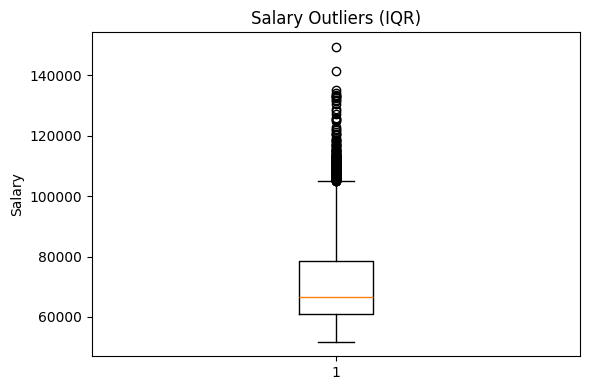

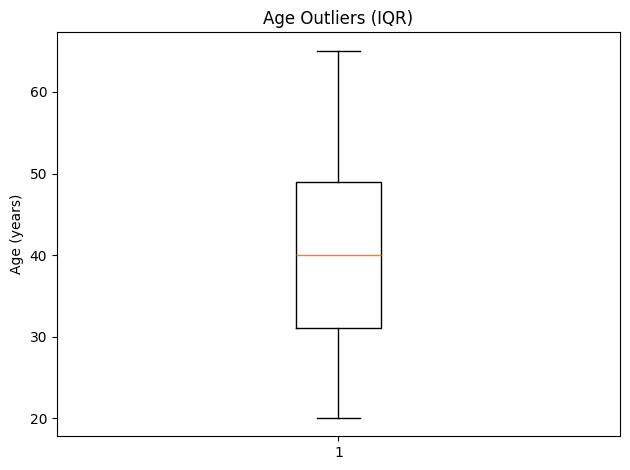

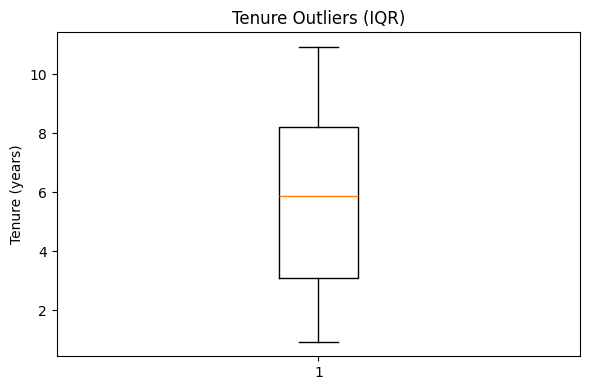

In [87]:
# Salary and Tenure Outliers (Boxplots using IQR)

# Salary boxplot
salary_data = df['salary'].dropna()
plt.figure(figsize=(6, 4))
plt.boxplot(salary_data)
plt.title('Salary Outliers (IQR)')
plt.ylabel('Salary')
plt.tight_layout()
plt.show()

# Age boxplot
age_data = df["age_years"].dropna()
plt.figure()
plt.boxplot(age_data)
plt.title("Age Outliers (IQR)")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

# Tenure boxplot
tenure_data = df['tenure_years'].dropna()
plt.figure(figsize=(6, 4))
plt.boxplot(tenure_data)
plt.title('Tenure Outliers (IQR)')
plt.ylabel('Tenure (years)')
plt.tight_layout()
plt.show()


## Bar Chart of missing % by column

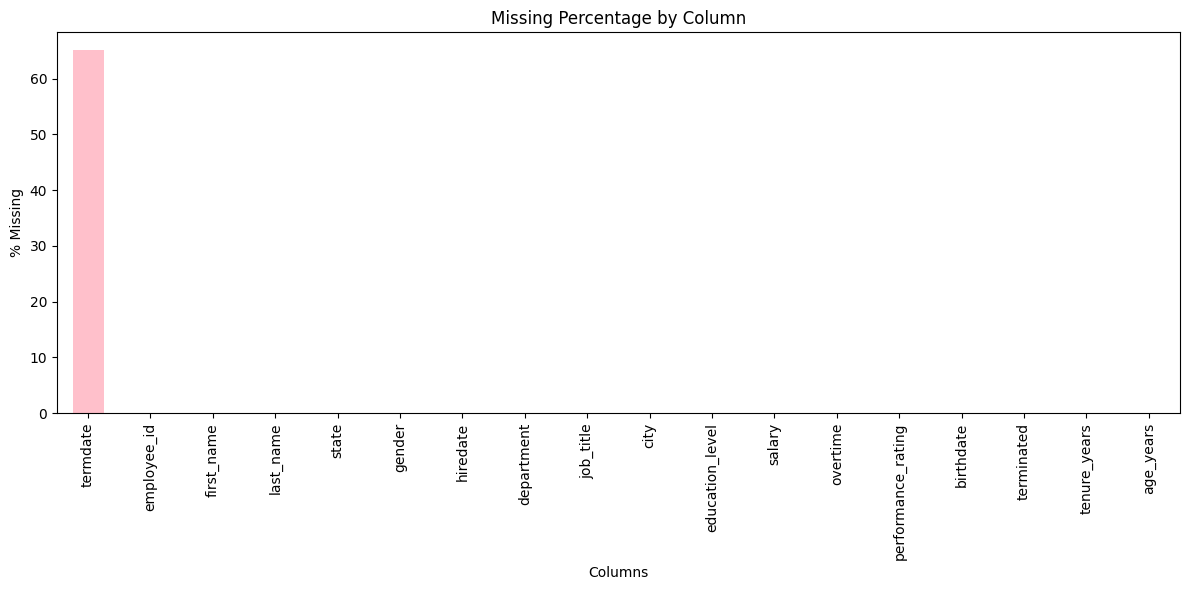

In [88]:
miss_by_col = df.isna().mean() * 100
miss_by_col_sorted = miss_by_col.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
miss_by_col_sorted.plot(kind="bar", color="pink")
plt.title("Missing Percentage by Column")
plt.xlabel("Columns")
plt.ylabel("% Missing")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Heatmap of missingness patterns

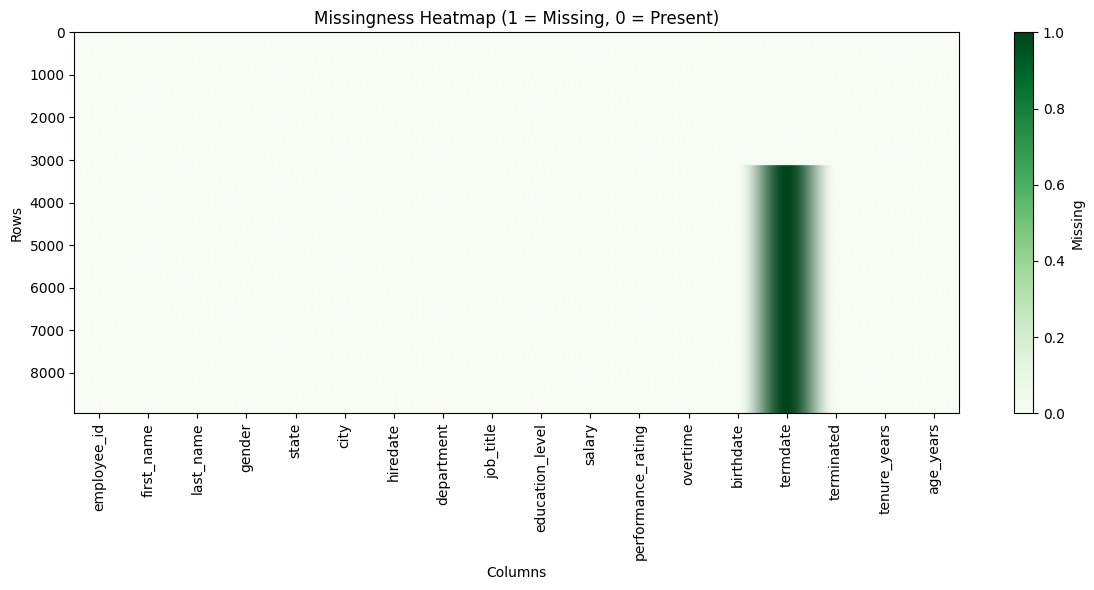

In [89]:
plt.figure(figsize=(12, 6))
plt.imshow(df.isna(), aspect="auto", cmap="Greens")
plt.title("Missingness Heatmap (1 = Missing, 0 = Present)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.colorbar(label="Missing")
plt.tight_layout()
plt.show()

## Correlation of missingness masks

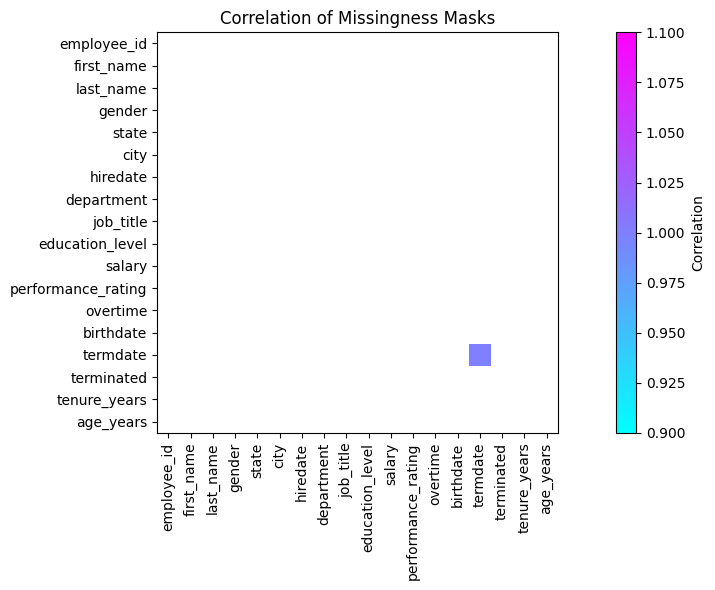

In [90]:
miss_of_mask = df.isna().astype(int)
corr_of_miss = miss_of_mask.corr()

plt.figure(figsize=(12, 6))
plt.imshow(corr_of_miss, cmap="cool", interpolation="nearest")
plt.title("Correlation of Missingness Masks")
plt.xticks(range(len(corr_of_miss.columns)), corr_of_miss.columns, rotation=90)
plt.yticks(range(len(corr_of_miss.columns)), corr_of_miss.columns)
plt.colorbar(label="Correlation")
plt.tight_layout()
plt.show()

In [91]:
# This step helps us understand the structure of the dataset by counting employees in each group and comparing them by gender

print("Employee count by department:")
print(df["department"].value_counts(), "\n")

print("Employee count by education_level:")
print(df["education_level"].value_counts(), "\n")

print("Employee count by overtime:")
print(df["overtime"].value_counts(), "\n")

print("Employee count by performance_rating:")
print(df["performance_rating"].value_counts(), "\n")

print("Employee count by job_title:")
print(df["job_title"].value_counts(), "\n")

print("Employee count by birthdate:")
print(df["birthdate"].value_counts(), "\n")

print("Employee count by hiredate:")
print(df["hiredate"].value_counts(), "\n")

dept_gender = pd.crosstab(df["department"], df["gender"])
print("Department x Gender table:")
print(dept_gender.head(), "\n")

dept_gender = pd.crosstab(df["education_level"], df["gender"])
print("Education_level x Gender table:")
print(dept_gender.head(), "\n")

dept_gender = pd.crosstab(df["overtime"], df["gender"])
print("Overtime x Gender table:")
print(dept_gender.head(), "\n")

dept_gender = pd.crosstab(df["performance_rating"], df["gender"])
print("Performance_rating x Gender table:")
print(dept_gender.head(), "\n")

dept_gender = pd.crosstab(df["job_title"], df["gender"])
print("Job_title x Gender table:")
print(dept_gender.head(), "\n")

dept_gender = pd.crosstab(df["birthdate"], df["gender"])
print("Birthdate x Gender table:")
print(dept_gender.head(), "\n")

dept_gender = pd.crosstab(df["hiredate"], df["gender"])
print("Hiredate x Gender table:")
print(dept_gender.head(), "\n")

Employee count by department:
department
Operations          2718
Sales               1835
Customer Service    1673
IT                  1382
Marketing            718
Finance              452
HR                   172
Name: count, dtype: int64 

Employee count by education_level:
education_level
Bachelor       5418
High School    1819
Master         1235
PhD             478
Name: count, dtype: int64 

Employee count by overtime:
overtime
No     6240
Yes    2710
Name: count, dtype: int64 

Employee count by performance_rating:
performance_rating
Good                 4449
Satisfactory         2671
Excellent            1112
Needs Improvement     718
Name: count, dtype: int64 

Employee count by job_title:
job_title
Logistics Coordinator              1061
Inventory Specialist               1044
Sales Representative                740
Software Developer                  627
Support Specialist                  608
Sales Specialist                    565
Operations Analyst                  557


In [92]:
#Investigate terminated by gender, education level, department, overtime, performance rating, job title, birthdate, and hiredate
terminated_by_gender = df.groupby("gender")["terminated"].agg(["mean", "median", "count"])
print("terminated by gender:")
print(terminated_by_gender, "\n")

terminated_by_edu = df.groupby("education_level")["terminated"].agg(["mean", "median", "count"])
print("terminated by education level:")
print(terminated_by_edu, "\n")

terminated_by_dept = df.groupby("department")["terminated"].agg(["mean", "median", "count"])
print("terminated by department:")
print(terminated_by_dept, "\n")

terminated_by_dept = df.groupby("overtime")["terminated"].agg(["mean", "median", "count"])
print("terminated by overtime:")
print(terminated_by_dept, "\n")

terminated_by_dept = df.groupby("performance_rating")["terminated"].agg(["mean", "median", "count"])
print("terminated by performance_rating:")
print(terminated_by_dept, "\n")

terminated_by_dept = df.groupby("job_title")["terminated"].agg(["mean", "median", "count"])
print("terminated by job title:")
print(terminated_by_dept, "\n")

terminated_by_dept = df.groupby("birthdate")["terminated"].agg(["mean", "median", "count"])
print("terminated by birthdate:")
print(terminated_by_dept, "\n")

terminated_by_dept = df.groupby("hiredate")["terminated"].agg(["mean", "median", "count"])
print("terminated by hiredate:")
print(terminated_by_dept, "\n")

terminated by gender:
            mean  median  count
gender                         
Female  0.353097     0.0   4149
Male    0.346386     0.0   4801 

terminated by education level:
                     mean  median  count
education_level                         
Bachelor         0.353082     0.0   5418
High School      0.349643     0.0   1819
Master           0.342510     0.0   1235
PhD              0.326360     0.0    478 

terminated by department:
                      mean  median  count
department                               
Customer Service  0.335923     0.0   1673
Finance           0.391593     0.0    452
HR                0.360465     0.0    172
IT                0.348046     0.0   1382
Marketing         0.339833     0.0    718
Operations        0.352833     0.0   2718
Sales             0.350409     0.0   1835 

terminated by overtime:
              mean  median  count
overtime                         
No        0.355288     0.0   6240
Yes       0.336162     0.0   2710 

t

# Descriptive Analysis:

In [93]:
# Summary statistics for numeric variables columns
df.describe()

,hiredate,salary,birthdate,terminated,tenure_years,age_years
count,8950,8950.000000,8950,8950.000000,8950.000000,8950.000000
mean,2020-03-15 18:43:12.000000256,70945.777765,1985-07-18 17:28:13.407821184,0.349497,5.725448,40.384044
min,2015-01-01 00:00:00,51835.000000,1960-11-16 00:00:00,0.000000,0.936345,20.062971
25%,2017-09-13 00:00:00,60920.500000,1976-11-26 06:00:00,0.000000,3.077344,31.131417
50%,2020-01-24 00:00:00,66592.000000,1985-12-11 12:00:00,0.000000,5.867214,39.984942
75%,2022-11-08 00:00:00,78558.500000,1994-10-19 06:00:00,1.000000,8.229979,49.026010
max,2024-12-29 00:00:00,149377.000000,2005-11-13 00:00:00,1.000000,10.929500,65.054073
std,NaN,13736.763444,NaN,0.476838,2.811093,11.433483


## Histograms for numeric variables columns

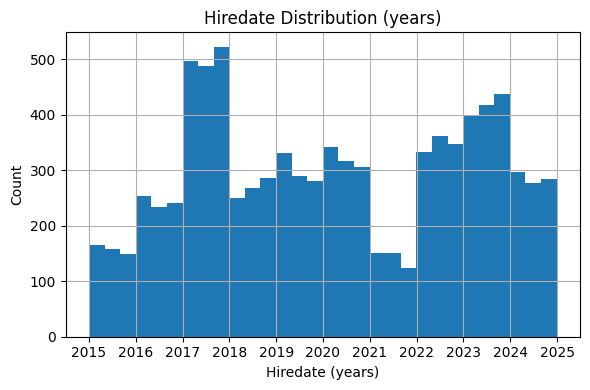

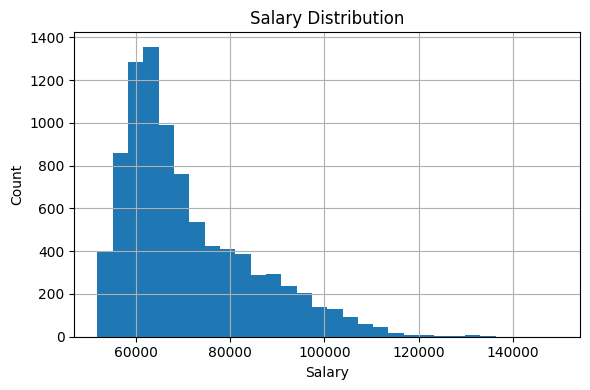

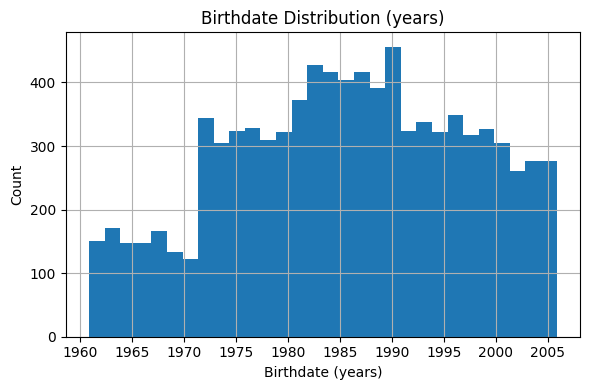

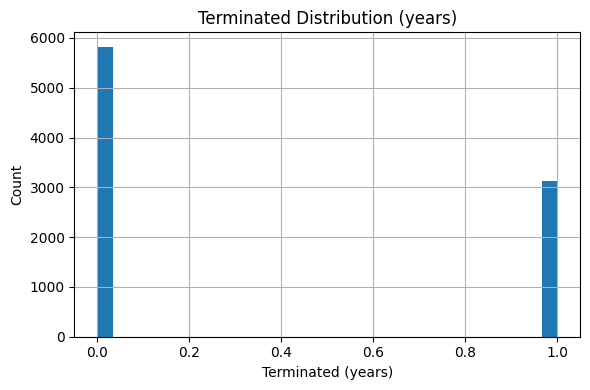

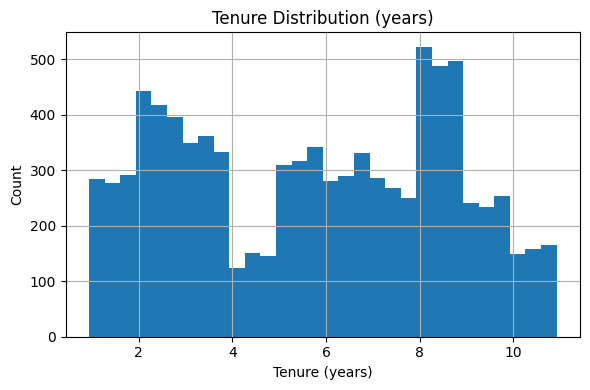

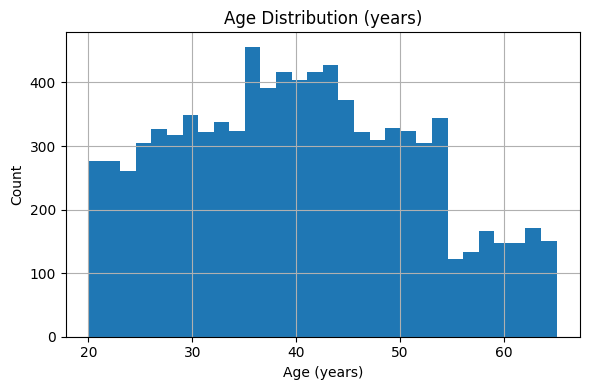

In [94]:
# Hiredate
plt.figure(figsize=(6, 4))
df['hiredate'].dropna().hist(bins=30)
plt.title('Hiredate Distribution (years)')
plt.xlabel('Hiredate (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Salary
plt.figure(figsize=(6, 4))
df['salary'].dropna().hist(bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Birthdatte
plt.figure(figsize=(6, 4))
df['birthdate'].dropna().hist(bins=30)
plt.title('Birthdate Distribution (years)')
plt.xlabel('Birthdate (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Terminated
plt.figure(figsize=(6, 4))
df['terminated'].dropna().hist(bins=30)
plt.title('Terminated Distribution (years)')
plt.xlabel('Terminated (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Tenure_years
plt.figure(figsize=(6, 4))
df['tenure_years'].dropna().hist(bins=30)
plt.title('Tenure Distribution (years)')
plt.xlabel('Tenure (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Age_years
plt.figure(figsize=(6, 4))
df['age_years'].dropna().hist(bins=30)
plt.title('Age Distribution (years)')
plt.xlabel('Age (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Bar graphs to show terminated employees

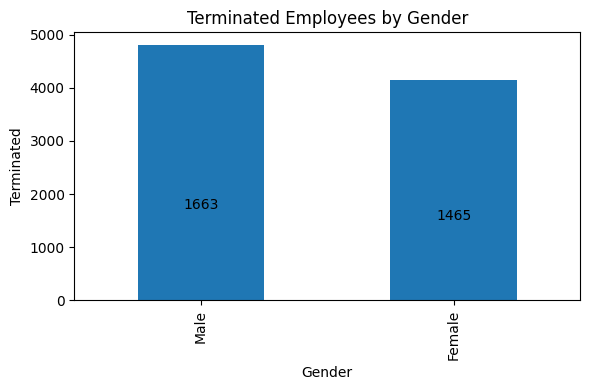

In [95]:
# Terminated Employees by Gender
plt.figure(figsize=(6,4))
terminated_counts = df[df["terminated"] == 1]["gender"].value_counts()
ax = terminated_counts.plot(kind="bar")
df['gender'].value_counts().plot(kind='bar')
plt.title("Terminated Employees by Gender")
plt.xlabel("Gender")
plt.ylabel("Terminated")
for i, value in enumerate(terminated_counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

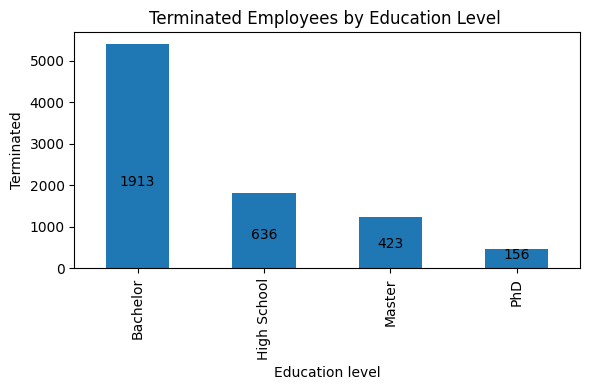

In [96]:
# Terminated Employees by Education Level
plt.figure(figsize=(6,4))
terminated_counts = df[df["terminated"] == 1]["education_level"].value_counts()
ax = terminated_counts.plot(kind="bar")
df['education_level'].value_counts().plot(kind='bar')
plt.title("Terminated Employees by Education Level ")
plt.xlabel("Education level")
plt.ylabel("Terminated")
for i, value in enumerate(terminated_counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

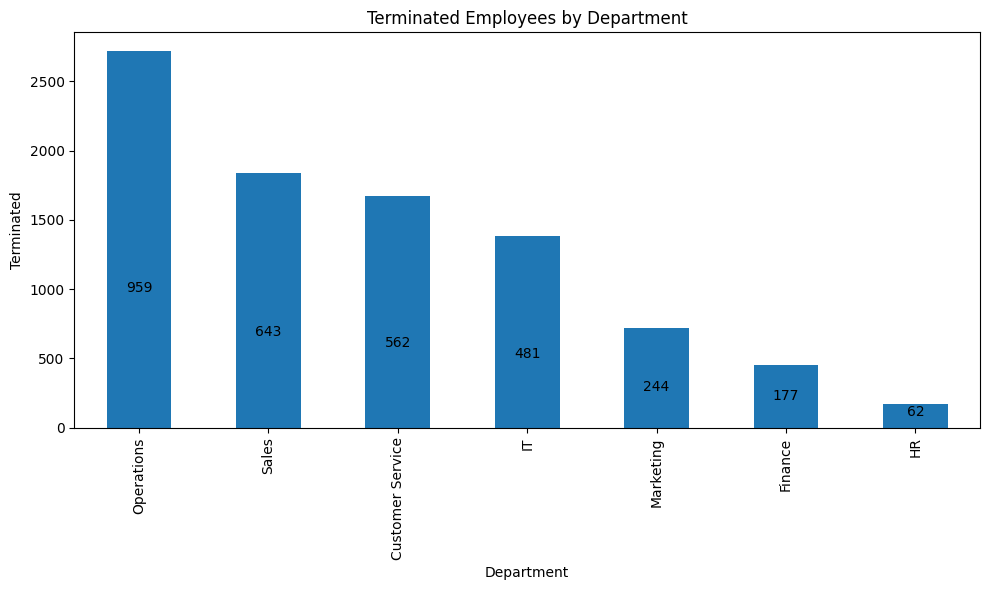

In [97]:
# Terminated Employees by Department
plt.figure(figsize=(10,6))
terminated_counts = df[df["terminated"] == 1]["department"].value_counts()
ax = terminated_counts.plot(kind="bar")
df['department'].value_counts().plot(kind='bar')
plt.title("Terminated Employees by Department")
plt.xlabel("Department")
plt.ylabel("Terminated")
for i, value in enumerate(terminated_counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

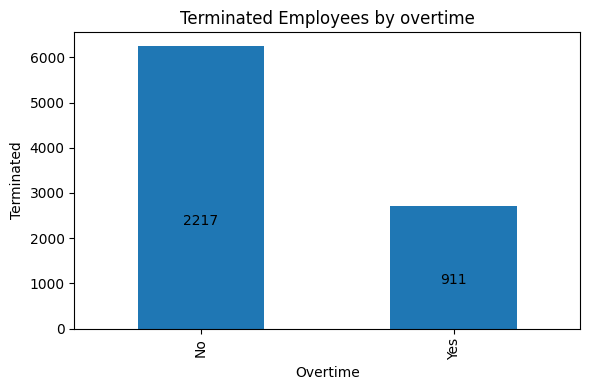

In [98]:
# Terminated Employees by Overtime
plt.figure(figsize=(6,4))
terminated_counts = df[df["terminated"] == 1]["overtime"].value_counts()
ax = terminated_counts.plot(kind="bar")
df['overtime'].value_counts().plot(kind='bar')
plt.title("Terminated Employees by overtime")
plt.xlabel("Overtime")
plt.ylabel("Terminated")
for i, value in enumerate(terminated_counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

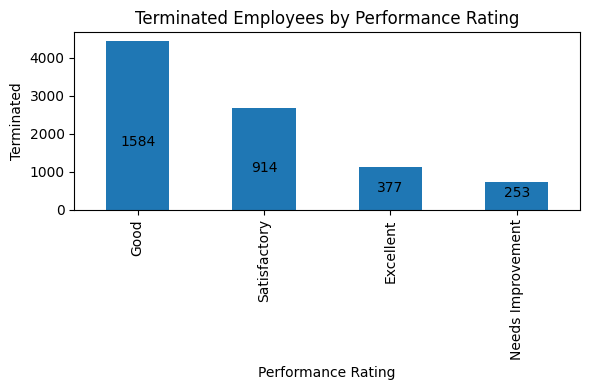

In [99]:
# Terminated Employees by Performance Rating
plt.figure(figsize=(6,4))
terminated_counts = df[df["terminated"] == 1]["performance_rating"].value_counts()
ax = terminated_counts.plot(kind="bar")
df['performance_rating'].value_counts().plot(kind='bar')
plt.title("Terminated Employees by Performance Rating")
plt.xlabel("Performance Rating")
plt.ylabel("Terminated")
for i, value in enumerate(terminated_counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

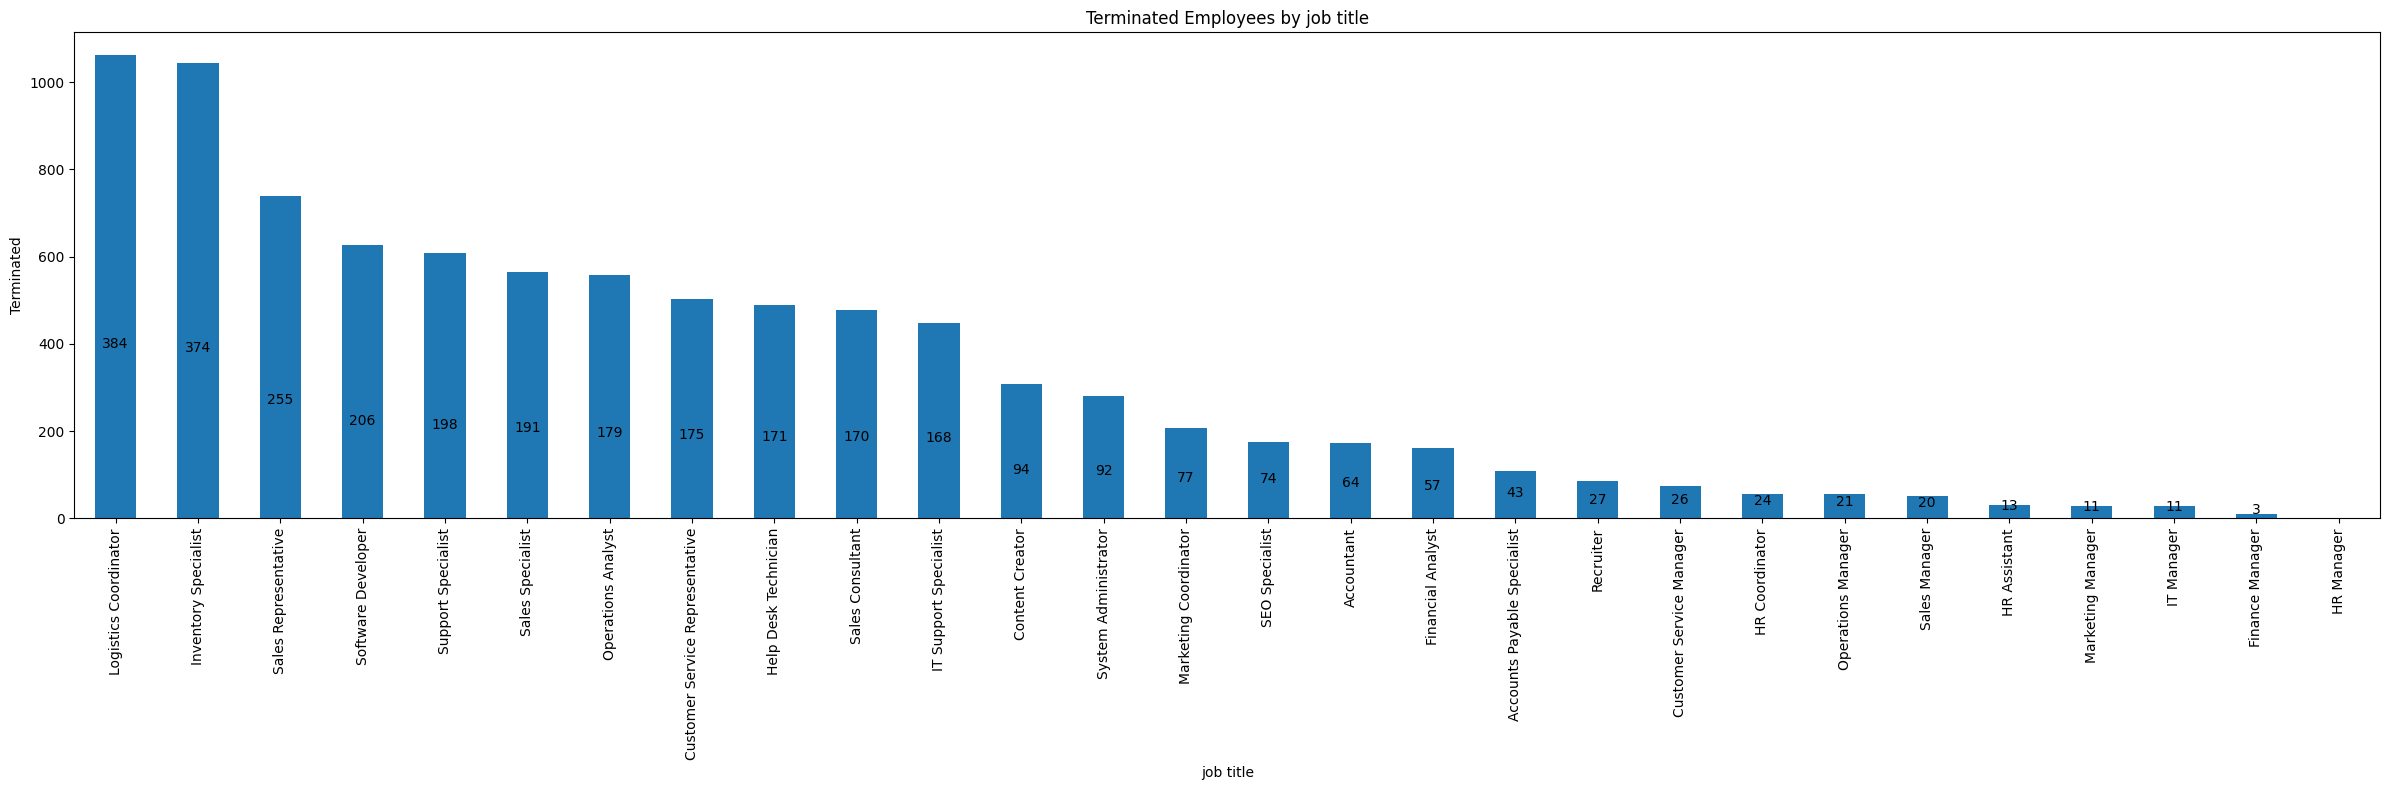

In [100]:
# Terminated Employees by Job Title
plt.figure(figsize=(24,8))
terminated_counts = df[df["terminated"] == 1]["job_title"].value_counts()
ax = terminated_counts.plot(kind="bar")
df['job_title'].value_counts().plot(kind='bar')
plt.title("Terminated Employees by job title")
plt.xlabel("job title")
plt.ylabel("Terminated")
for i, value in enumerate(terminated_counts.values):
    ax.text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

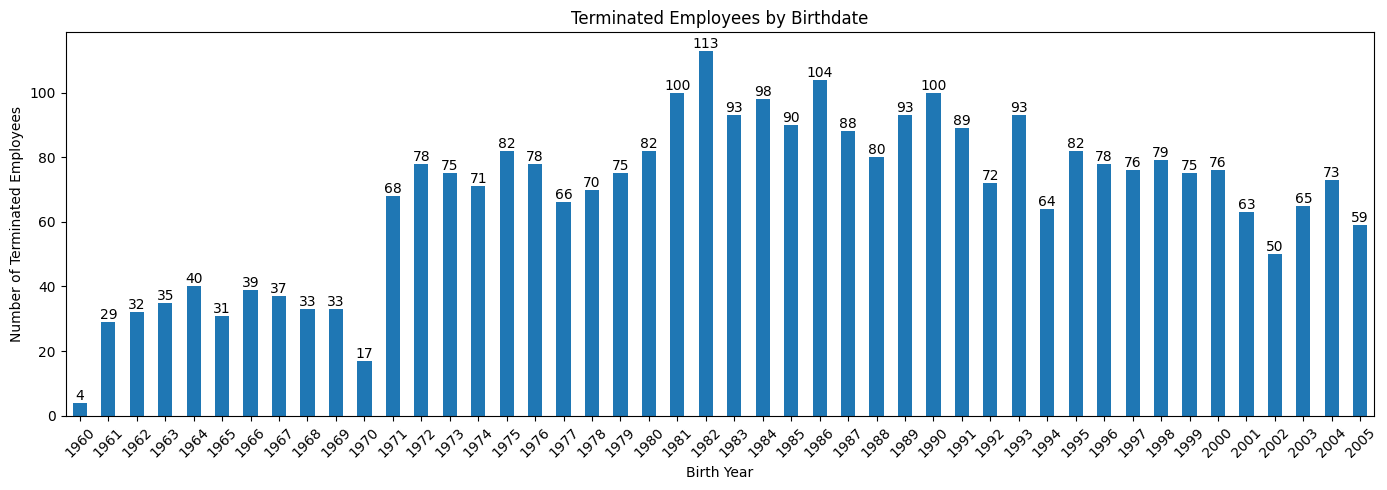

In [101]:
# Terminated Employees by Birthdate

# Ensure birthdate is datetime
df['birthdate'] = pd.to_datetime(df['birthdate'], errors='coerce')

# Keep only terminated employees
terminated_df = df[df['terminated'] == 1].copy()
terminated_df = terminated_df.dropna(subset=['birthdate'])
terminated_df['birth_year'] = terminated_df['birthdate'].dt.year

# Correct any future-shifted years (e.g., 2060s → 1960s)
terminated_df['birth_year'] = terminated_df['birth_year'].apply(
    lambda x: x - 100 if x is not None and x > 2025 else x
)

# Count terminated employees by birth year
yearly_terminated = terminated_df['birth_year'].value_counts().sort_index()

# Plot
plt.figure(figsize=(14, 5))
ax = yearly_terminated.plot(kind='bar')
plt.title('Terminated Employees by Birthdate')
plt.xlabel('Birth Year')
plt.ylabel('Number of Terminated Employees')
plt.xticks(rotation=45)
for i, value in enumerate(yearly_terminated.values):
    ax.text(i, value, str(value), ha='center', va='bottom')
plt.tight_layout()
plt.show()


/tmp/ipython-input-1649789902.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  terminated_df["hire_year"] = terminated_df["hiredate"].dt.year


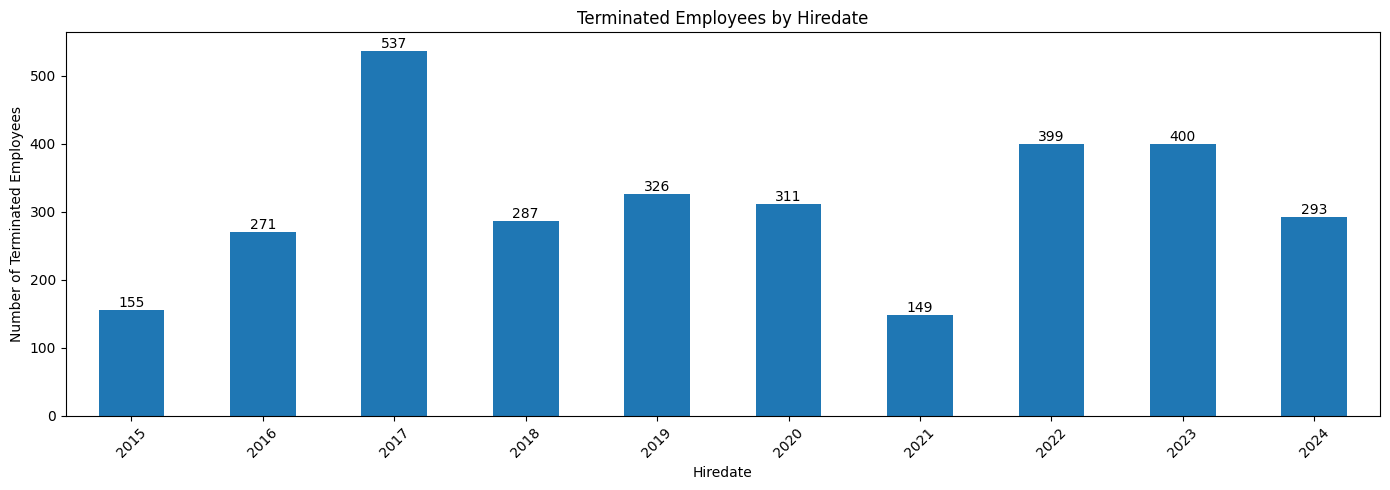

In [102]:
# Terminated Employees by Hiredate

# Convert hiredate to datetime
df["hiredate"] = pd.to_datetime(df["hiredate"], errors="coerce")

# Keep only terminated employees
terminated_df = df[df["terminated"] == 1]

# Convert hiredate to hire year
terminated_df["hire_year"] = terminated_df["hiredate"].dt.year

# Count terminations by hire year
yearly_terminated = terminated_df["hire_year"].value_counts().sort_index()

# Plot
plt.figure(figsize=(14, 5))
ax = yearly_terminated.plot(kind="bar")

plt.title("Terminated Employees by Hiredate")
plt.xlabel("Hiredate")
plt.ylabel("Number of Terminated Employees")
plt.xticks(rotation=45)

# Add actual numbers on each bar
for i, value in enumerate(yearly_terminated.values):
    ax.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()


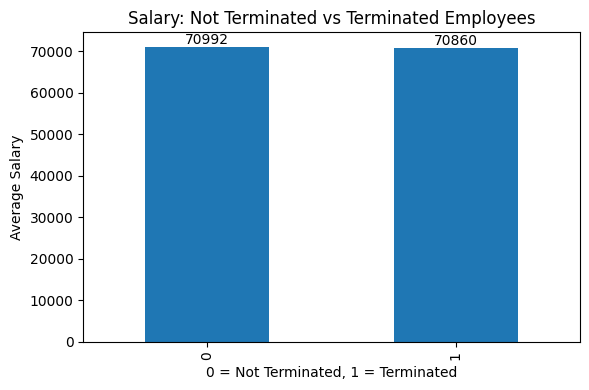

In [103]:
# Compare salary between terminated vs not terminated employees
plt.figure(figsize=(6, 4))

# Average salary by termination status
avg_salary = df.groupby("terminated")["salary"].mean()

ax = avg_salary.plot(kind="bar")

plt.title("Salary: Not Terminated vs Terminated Employees")
plt.xlabel("0 = Not Terminated, 1 = Terminated")
plt.ylabel("Average Salary")

# Add the average salary on each bar
for i, value in enumerate(avg_salary.values):
    ax.text(i, value, f"{value:.0f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


In [104]:
# Rechecking People who are terminated and not terminated (0 = not terminated, 1 = terminated)
df['terminated'].value_counts()

,count
terminated,
0,5822
1,3128


## Feature Engineering

In [105]:
df.head(10)

,employee_id,first_name,last_name,gender,state,city,hiredate,department,job_title,education_level,salary,performance_rating,overtime,birthdate,termdate,terminated,tenure_years,age_years
0,00-95822412,Danielle,Johnson,Female,New York,Buffalo,2016-04-10,Customer Service,Help Desk Technician,High School,81552,Good,No,1981-05-13,2017-08-09,1,9.656400,44.566735
1,00-42868828,Jeffrey,Doyle,Male,North Carolina,Charlotte,2017-09-04,IT,System Administrator,Bachelor,107520,Good,No,1988-12-21,2021-01-15,1,8.254620,36.958248
2,00-83197857,Patricia,Miller,Male,New York,New York City,2016-06-03,Operations,Logistics Coordinator,Bachelor,61104,Good,Yes,1995-04-19,2016-11-30,1,9.508556,30.633812
3,00-13999315,Anthony,Robinson,Male,New York,Rochester,2016-07-03,Operations,Inventory Specialist,Bachelor,73770,Good,No,1981-03-24,2020-02-09,1,9.426420,44.703628
4,00-90801586,Anthony,Gonzalez,Female,New York,Rochester,2015-08-25,Operations,Operations Analyst,Bachelor,55581,Satisfactory,No,1985-12-01,2021-05-12,1,10.283368,40.013689
5,00-97226012,Amy,Robinson,Female,New York,New York City,2022-08-03,Operations,Operations Analyst,Bachelor,73800,Good,Yes,1990-07-17,2023-09-23,1,3.342916,35.389459
6,00-70291817,Lisa,Smith,Male,New York,Buffalo,2020-10-21,Finance,Accountant,Bachelor,68181,Good,No,1993-09-01,2021-04-19,1,5.125257,32.262834
7,00-31429110,Helen,Peterson,Female,New York,Buffalo,2022-02-26,Finance,Accounts Payable Specialist,Bachelor,54499,Good,Yes,1997-09-10,2022-08-25,1,3.775496,28.238193
8,00-30868105,Susan,Rogers,Male,New York,Buffalo,2017-02-03,Operations,Inventory Specialist,High School,57340,Good,No,2003-01-29,2021-06-26,1,8.837782,22.852841
9,00-22448136,Colin,Abbott,Female,New York,Rochester,2018-08-08,Operations,Logistics Coordinator,Bachelor,54065,Good,Yes,1982-03-05,2023-01-30,1,7.329227,43.756331


In [106]:
df.dtypes

,0
employee_id,object
first_name,object
last_name,object
gender,object
state,object
city,object
hiredate,datetime64[ns]
department,object
job_title,object
education_level,object


In [107]:
# Import required libraries
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE


In [108]:

# Load dataset
df = pd.read_csv("HumanResources-Dataset.csv", parse_dates=['hiredate', 'birthdate', 'termdate'])

# ---------------------------
# 1. Feature Engineering
# ---------------------------

# Clean 'termdate': empty or invalid strings → pd.NaT
df['termdate'] = pd.to_datetime(df['termdate'], errors='coerce')

# Calculate age (as of 2025-12-06 — the current actual date you provided)
current_date = pd.to_datetime("2025-12-06")
df['age'] = (current_date - df['birthdate']).dt.days // 365

# Calculate tenure (in years)
df['tenure'] = np.where(
    df['termdate'].isna(),
    (current_date - df['hiredate']).dt.days // 365,
    (df['termdate'] - df['hiredate']).dt.days // 365
)

# Target variable: terminated (1 if termdate is not null, else 0)
df['terminated'] = (~df['termdate'].isna()).astype(int)

# Convert overtime to binary
df['overtime_binary'] = (df['overtime'] == 'Yes').astype(int)



In [109]:
# ---------------------------
# 2. Encoding Categoricals
# ---------------------------

# Binary encoding: gender
df['gender_binary'] = (df['gender'] == 'Male').astype(int)  # Optional: or use LabelEncoder

# Ordinal encoding
edu_order = ['High School', 'Bachelor', 'Master', 'PhD']
perf_order = ['Needs Improvement', 'Satisfactory', 'Good', 'Excellent']

df['education_ordinal'] = OrdinalEncoder(categories=[edu_order]).fit_transform(df[['education_level']])
df['performance_ordinal'] = OrdinalEncoder(categories=[perf_order]).fit_transform(df[['performance_rating']])

# One-hot encoding for state, city, department, job_title
# To avoid explosion due to many unique values, consider grouping rare categories or limiting
# Here, we'll encode all (assuming dataset ~200-300 rows — safe)

cat_cols = ['state', 'city', 'department', 'job_title']
df_encoded = pd.get_dummies(df, columns=cat_cols, prefix=cat_cols, drop_first=True)



In [110]:
# ---------------------------
# 3. Final feature selection
# ---------------------------

# Select numeric + engineered + encoded cols (drop raw dates, original categoricals, and raw overtime/gender)
drop_cols = [
    'employee_id', 'first_name', 'last_name', 'gender', 'state', 'city',
    'hiredate', 'birthdate', 'termdate', 'department', 'job_title',
    'education_level', 'performance_rating', 'overtime',
    'salary', 'age', 'tenure', 'terminated', 'overtime_binary',
    'gender_binary', 'education_ordinal', 'performance_ordinal'
]

numeric_cols = ['salary', 'age', 'tenure']
engineered_cols = ['overtime_binary', 'gender_binary', 'education_ordinal', 'performance_ordinal']

# Build final feature matrix
X = df_encoded[numeric_cols + engineered_cols + [col for col in df_encoded.columns if col not in drop_cols]]
y = df_encoded['terminated']



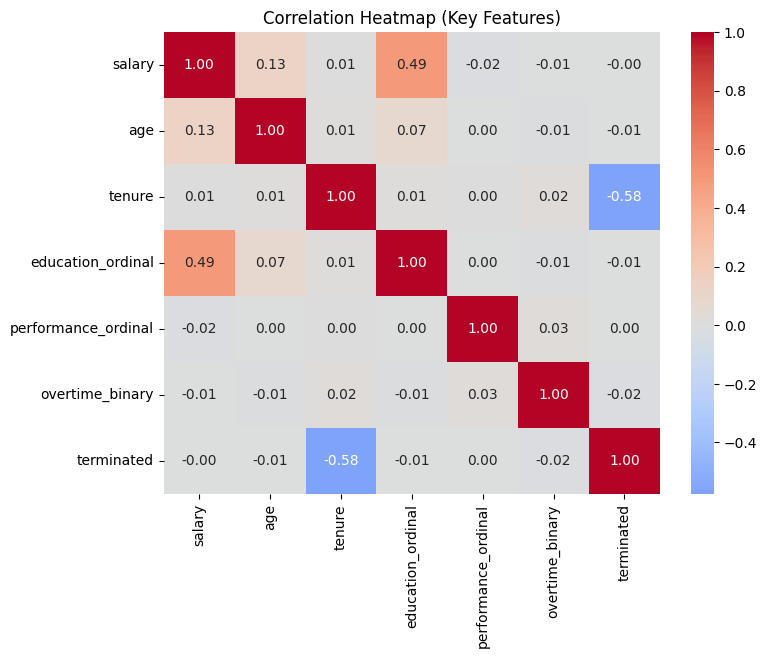

In [111]:
# ---------------------------
# 4. Correlation Analysis (focused)
# ---------------------------

# Focus only on key numeric/ordinal features + target
corr_df = df[['salary', 'age', 'tenure', 'education_ordinal', 'performance_ordinal', 'overtime_binary', 'terminated']].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
plt.title("Correlation Heatmap (Key Features)")
plt.show()



In [112]:
# ---------------------------
# 5. Train/Test Split + Scaling
# ---------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numeric features only (age, tenure, salary)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])



In [113]:
# ---------------------------
# 6. Logistic Regression (Baseline)
# ---------------------------

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
print("=== Baseline Logistic Regression (Balanced Class Weight) ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1]))



=== Baseline Logistic Regression (Balanced Class Weight) ===
              precision    recall  f1-score   support

           0       0.86      0.67      0.75      1164
           1       0.56      0.79      0.66       626

    accuracy                           0.71      1790
   macro avg       0.71      0.73      0.71      1790
weighted avg       0.76      0.71      0.72      1790

ROC-AUC: 0.8587428499280875



=== Logistic Regression After SMOTE ===
              precision    recall  f1-score   support

           0       0.85      0.72      0.78      1164
           1       0.59      0.76      0.67       626

    accuracy                           0.73      1790
   macro avg       0.72      0.74      0.72      1790
weighted avg       0.76      0.73      0.74      1790

ROC-AUC: 0.8540026678963144


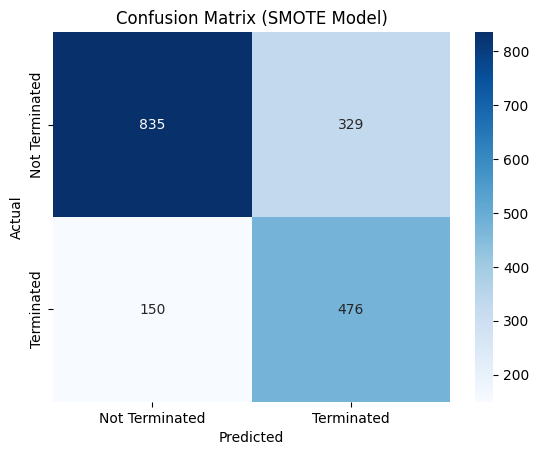


Top 10 Features by Absolute Coefficient (SMOTE Model):
                                      feature      coef
15                               city_Buffalo  2.986377
33                             city_Rochester  2.985921
26                         city_New York City  2.801626
24                                 city_Miami  2.446600
46  job_title_Customer Service Representative  2.368985
52             job_title_Help Desk Technician  2.322368
64                    job_title_Sales Manager  2.288946
12                         state_Pennsylvania  2.288712
37                         department_Finance  2.271704
68               job_title_Support Specialist  2.262361


In [114]:
# ---------------------------
# 7. SMOTE + Retrain
# ---------------------------

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

lr_smote = LogisticRegression(max_iter=1000, random_state=42)  # no class_weight — now balanced
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test_scaled)
y_proba_smote = lr_smote.predict_proba(X_test_scaled)[:,1]

print("\n=== Logistic Regression After SMOTE ===")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_smote))

# Optional: Confusion Matrix for SMOTE model
cm = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Terminated','Terminated'], yticklabels=['Not Terminated','Terminated'])
plt.title("Confusion Matrix (SMOTE Model)")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.show()

# Optional: Feature importance (coefficients)
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': lr_smote.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

print("\nTop 10 Features by Absolute Coefficient (SMOTE Model):")
print(coef_df.head(10))